# Determine And Validate The Preprocessing Rules

## Purpose

**This notebook finalizes preprocessing for clinical variables after EDA filtering.**

### Objectives:
- Review remaining missingness in retained clinical features
- Define deterministic handling rules (drop vs. impute)
- Implement train-fit imputation (fit on train, apply to val/test)
- Document preprocessing decisions for the integration guide

### Workflow

1. Load filtered clinical dataset  
   - Dataset already passed validity filtering during EDA.

2. Inspect remaining missingness (full cohort)  
   - Confirm missingness rates for all retained columns.  
   - Verify column types (numeric vs categorical).

3. Remove constant columns  
   - Drop columns containing only a single category across the cohort.

4. Check and handle redundant columns  
   - Identify redundant numerical and categorical encodings.  
   - Retain a single canonical representation for each concept.

5. Encode preprocessing rules  
   - Store deterministic decisions in variables/lists:
       • manual drop columns  
       • numeric imputation columns  
       • categorical imputation columns  
       • missingness indicator columns

6. Load split IDs and partition the dataset  
   - Create `X_train`, `X_val`, `X_test` using the saved split.

7. Fit imputation parameters on the training set only  
   - Compute medians / modes using `X_train`.

8. Apply imputations to all splits  
   - Transform train, validation, and test using parameters learned from the training set.

9. Validate outputs  
   - Confirm no remaining missing values  
   - Verify row counts match split sizes  
   - Verify no ID drift or leakage

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as ss
from IPython.display import display

import seaborn as sns
import matplotlib.pyplot as plt


## 1. Load filtered clinical dataset

In [2]:
# Load clinical features dataset

clinical_path = Path('../data/interim/clinical_features_filtered.csv')

if clinical_path is None:
    raise FileNotFoundError(f'Could not find dataset in any of: {clinical_path}')

clin_df = pd.read_csv(clinical_path)

# Data-integrity checks.
if clin_df.empty:
    raise ValueError('clinical_features_filtered.csv is empty')

if clin_df.columns.duplicated().any():
    dup_cols = clin_df.columns[clin_df.columns.duplicated()].tolist()
    raise ValueError(f'Duplicate column names detected: {dup_cols}')

print(f'Loaded: {clinical_path}')
print(f'Rows: {clin_df.shape[0]:,} | Columns: {clin_df.shape[1]:,}')
display(clin_df.head())


Loaded: ../data/interim/clinical_features_filtered.csv
Rows: 290 | Columns: 54


,disease_type,primary_site,alcohol_history.exposures,race.demographic,gender.demographic,ethnicity.demographic,vital_status.demographic,age_at_index.demographic,days_to_birth.demographic,year_of_birth.demographic,...,tumor_descriptor.samples,sample_type.samples,composition.samples,days_to_collection.samples,initial_weight.samples,preservation_method.samples,oct_embedded.samples,specimen_type.samples,is_ffpe.samples,tissue_type.samples
0,Ductal and Lobular Neoplasms,Breast,Not Reported,white,female,not hispanic or latino,Alive,55.0,-20211.0,1949.0,...,Primary,Primary Tumor,Not Reported,3599.0,60.0,OCT,True,Solid Tissue,False,Tumor
1,Ductal and Lobular Neoplasms,Breast,Not Reported,black or african american,female,not hispanic or latino,Alive,50.0,-18538.0,1953.0,...,Primary,Primary Tumor,Not Reported,3772.0,120.0,OCT,True,Solid Tissue,False,Tumor
2,"Epithelial Neoplasms, NOS",Breast,Not Reported,asian,female,not hispanic or latino,Dead,54.0,-20048.0,1953.0,...,Primary,Primary Tumor,Not Reported,1164.0,160.0,OCT,True,Solid Tissue,False,Tumor
3,Ductal and Lobular Neoplasms,Breast,Not Reported,white,female,hispanic or latino,Alive,66.0,-24155.0,1936.0,...,Primary,Primary Tumor,Not Reported,2850.0,130.0,OCT,True,Solid Tissue,False,Tumor
4,Ductal and Lobular Neoplasms,Breast,Not Reported,white,female,not reported,Alive,48.0,-17660.0,1956.0,...,Primary,Primary Tumor,Not Reported,2260.0,230.0,OCT,True,Solid Tissue,False,Tumor


## 2. Inspect remaining missingness (full cohort)

In [3]:
# Check missingness patterns and column types to inform imputation strategy.

missing_rate = clin_df.isna().mean().sort_values(ascending=False)

numeric_cols = clin_df.select_dtypes(include=['number', 'bool']).columns
categorical_cols = clin_df.columns.difference(numeric_cols, sort=False)

# Integrity check: every column is classified exactly once.
if len(set(numeric_cols).intersection(set(categorical_cols))) != 0:
    raise ValueError('Column type overlap detected between numeric and categorical')

if len(numeric_cols) + len(categorical_cols) != clin_df.shape[1]:
    raise ValueError('Some columns were not classified as numeric or categorical')

col_audit = pd.DataFrame({
    'dtype': clin_df.dtypes.astype(str),
    'missing_rate': missing_rate.reindex(clin_df.columns),
    'missing_count': clin_df.isna().sum(),
})
col_audit['role'] = np.where(col_audit.index.isin(numeric_cols), 'numeric', 'categorical')
col_audit = col_audit.sort_values('missing_rate', ascending=False)

print('Missingness summary (all retained columns):')
display(col_audit)

print('Type counts:')
print(f"- numeric: {len(numeric_cols)}")
print(f"- categorical: {len(categorical_cols)}")

print('Columns with missingness > 0:')
display(col_audit.loc[col_audit['missing_rate'] > 0, ['dtype', 'role', 'missing_count', 'missing_rate']])


Missingness summary (all retained columns):


,dtype,missing_rate,missing_count,role
ajcc_staging_system_edition.diagnoses,object,0.093103,27,categorical
days_to_birth.demographic,float64,0.003448,1,numeric
age_at_earliest_diagnosis.diagnoses.xena_derived,float64,0.003448,1,numeric
age_at_earliest_diagnosis_in_years.diagnoses.xena_derived,float64,0.003448,1,numeric
age_at_diagnosis.diagnoses,float64,0.003448,1,numeric
initial_weight.samples,float64,0.003448,1,numeric
ethnicity.demographic,object,0.000000,0,categorical
vital_status.demographic,object,0.000000,0,categorical
age_at_index.demographic,float64,0.000000,0,numeric
year_of_birth.demographic,float64,0.000000,0,numeric


Type counts:
- numeric: 11
- categorical: 43
Columns with missingness > 0:


,dtype,role,missing_count,missing_rate
ajcc_staging_system_edition.diagnoses,object,categorical,27,0.093103
days_to_birth.demographic,float64,numeric,1,0.003448
age_at_earliest_diagnosis.diagnoses.xena_derived,float64,numeric,1,0.003448
age_at_earliest_diagnosis_in_years.diagnoses.xena_derived,float64,numeric,1,0.003448
age_at_diagnosis.diagnoses,float64,numeric,1,0.003448
initial_weight.samples,float64,numeric,1,0.003448


In [4]:
# Check all rows that have at least one missing value
rows_with_missing = clin_df[clin_df.isna().any(axis=1)]

print(f"Rows with >=1 missing value: {len(rows_with_missing):,}")
display(rows_with_missing)


Rows with >=1 missing value: 29


,disease_type,primary_site,alcohol_history.exposures,race.demographic,gender.demographic,ethnicity.demographic,vital_status.demographic,age_at_index.demographic,days_to_birth.demographic,year_of_birth.demographic,...,tumor_descriptor.samples,sample_type.samples,composition.samples,days_to_collection.samples,initial_weight.samples,preservation_method.samples,oct_embedded.samples,specimen_type.samples,is_ffpe.samples,tissue_type.samples
32,Ductal and Lobular Neoplasms,Breast,Not Reported,white,female,not hispanic or latino,Dead,82.0,-30085.0,1924.0,...,Primary,Primary Tumor,Not Reported,1337.0,680.0,OCT,True,Solid Tissue,False,Tumor
33,Ductal and Lobular Neoplasms,Breast,Not Reported,white,female,not hispanic or latino,Dead,66.0,-24235.0,1943.0,...,Primary,Primary Tumor,Not Reported,261.0,270.0,OCT,True,Solid Tissue,False,Tumor
34,Ductal and Lobular Neoplasms,Breast,Not Reported,white,female,not hispanic or latino,Dead,56.0,-20482.0,1952.0,...,Primary,Primary Tumor,Not Reported,884.0,950.0,OCT,True,Solid Tissue,False,Tumor
51,Ductal and Lobular Neoplasms,Breast,Not Reported,asian,female,not hispanic or latino,Alive,40.0,NaN,1966.0,...,Primary,Primary Tumor,Not Reported,1904.0,130.0,Unknown,False,Solid Tissue,False,Tumor
61,Ductal and Lobular Neoplasms,Breast,Not Reported,white,female,not hispanic or latino,Alive,57.0,-20930.0,1948.0,...,Primary,Primary Tumor,Not Reported,1608.0,140.0,OCT,True,Solid Tissue,False,Tumor
63,Ductal and Lobular Neoplasms,Breast,Not Reported,white,female,not hispanic or latino,Dead,48.0,-17815.0,1960.0,...,Primary,Primary Tumor,Not Reported,554.0,500.0,OCT,True,Solid Tissue,False,Tumor
64,Ductal and Lobular Neoplasms,Breast,Not Reported,white,female,not hispanic or latino,Alive,59.0,-21831.0,1946.0,...,Primary,Primary Tumor,Not Reported,1863.0,230.0,OCT,True,Solid Tissue,False,Tumor
65,Ductal and Lobular Neoplasms,Breast,Not Reported,black or african american,female,not hispanic or latino,Alive,53.0,-19516.0,1952.0,...,Primary,Primary Tumor,Not Reported,1910.0,550.0,OCT,True,Solid Tissue,False,Tumor
66,Ductal and Lobular Neoplasms,Breast,Not Reported,white,female,not hispanic or latino,Alive,68.0,-24923.0,1941.0,...,Primary,Primary Tumor,Not Reported,273.0,410.0,OCT,True,Solid Tissue,False,Tumor
67,Ductal and Lobular Neoplasms,Breast,Not Reported,white,female,not hispanic or latino,Alive,54.0,-19758.0,1952.0,...,Primary,Primary Tumor,Not Reported,1477.0,260.0,OCT,True,Solid Tissue,False,Tumor


In [5]:
# Check rows with >=1 missing value, restricted to columns that contain missing values
missing_cols = clin_df.columns[clin_df.isna().any(axis=0)]
rows_missing_cols_only = clin_df.loc[clin_df.isna().any(axis=1), missing_cols]

print(f"Columns with missing values: {len(missing_cols)}")
print(f"Rows with >=1 missing value: {rows_missing_cols_only.shape[0]:,}")
display(rows_missing_cols_only)


Columns with missing values: 6
Rows with >=1 missing value: 29


,days_to_birth.demographic,age_at_diagnosis.diagnoses,ajcc_staging_system_edition.diagnoses,age_at_earliest_diagnosis.diagnoses.xena_derived,age_at_earliest_diagnosis_in_years.diagnoses.xena_derived,initial_weight.samples
32,-30085.0,30085.0,NaN,30085.0,82.424658,680.0
33,-24235.0,24235.0,NaN,24235.0,66.397260,270.0
34,-20482.0,20482.0,NaN,20482.0,56.115068,950.0
51,NaN,NaN,6th,NaN,NaN,130.0
61,-20930.0,20930.0,NaN,20930.0,57.342466,140.0
63,-17815.0,17815.0,NaN,17815.0,48.808219,500.0
64,-21831.0,21831.0,NaN,21831.0,59.810959,230.0
65,-19516.0,19516.0,NaN,19516.0,53.468493,550.0
66,-24923.0,24923.0,NaN,24923.0,68.282192,410.0
67,-19758.0,19758.0,NaN,19758.0,54.131507,260.0


In [6]:
# Check staging system edition categories to inform imputation strategy for this column, which has ~20% missingness.
clin_df['ajcc_staging_system_edition.diagnoses'].value_counts(dropna=False)

ajcc_staging_system_edition.diagnoses
6th    187
5th     32
NaN     27
7th     26
4th     13
3rd      5
Name: count, dtype: int64

### Missingness summary
 - Missing age variables are single sample - can impute
 - Missing weight variable is a single sample - can impute
 - 'ajcc_staging_system_edition' is a categorical variable with 6 categories, set NaN values to 'unknown'

## 3. Remove constant columns  

In [7]:
# Flag and remove constant columns (including all-missing columns).
unique_counts = clin_df.nunique(dropna=False)
constant_cols = unique_counts[unique_counts <= 1].index.tolist()

print(f'Constant columns found: {len(constant_cols)}')
if constant_cols:
    display(pd.DataFrame({'column': constant_cols, 'n_unique': unique_counts.loc[constant_cols].values}))

n_cols_before = clin_df.shape[1]
clin_df = clin_df.drop(columns=constant_cols)
n_cols_after = clin_df.shape[1]

# Integrity check: verify expected number of columns were removed.
expected_after = n_cols_before - len(constant_cols)
if n_cols_after != expected_after:
    raise ValueError(
        f'Column-count mismatch after dropping constants: expected {expected_after}, got {n_cols_after}'
    )

print(f'Columns before: {n_cols_before}')
print(f'Columns after : {n_cols_after}')


Constant columns found: 20


,column,n_unique
0,primary_site,1
1,alcohol_history.exposures,1
2,primary_site.project,1
3,project_id.project,1
4,disease_type.project,1
5,name.project,1
6,name.program.project,1
7,project.tissue_source_site,1
8,bcr_id.tissue_source_site,1
9,last_known_disease_status.diagnoses,1


Columns before: 54
Columns after : 34


## 4. Check for redundant columns

High-correlation pairs (>0.95): 11


,feature_1,feature_2,corr
22,age_at_diagnosis.diagnoses,age_at_earliest_diagnosis.diagnoses.xena_derived,1.000000
11,days_to_birth.demographic,age_at_earliest_diagnosis.diagnoses.xena_derived,1.000000
9,days_to_birth.demographic,age_at_diagnosis.diagnoses,1.000000
30,age_at_earliest_diagnosis.diagnoses.xena_derived,age_at_earliest_diagnosis_in_years.diagnoses.x...,1.000000
23,age_at_diagnosis.diagnoses,age_at_earliest_diagnosis_in_years.diagnoses.x...,1.000000
12,days_to_birth.demographic,age_at_earliest_diagnosis_in_years.diagnoses.x...,1.000000
5,age_at_index.demographic,age_at_earliest_diagnosis_in_years.diagnoses.x...,0.999777
4,age_at_index.demographic,age_at_earliest_diagnosis.diagnoses.xena_derived,0.999777
2,age_at_index.demographic,age_at_diagnosis.diagnoses,0.999777
0,age_at_index.demographic,days_to_birth.demographic,0.999777


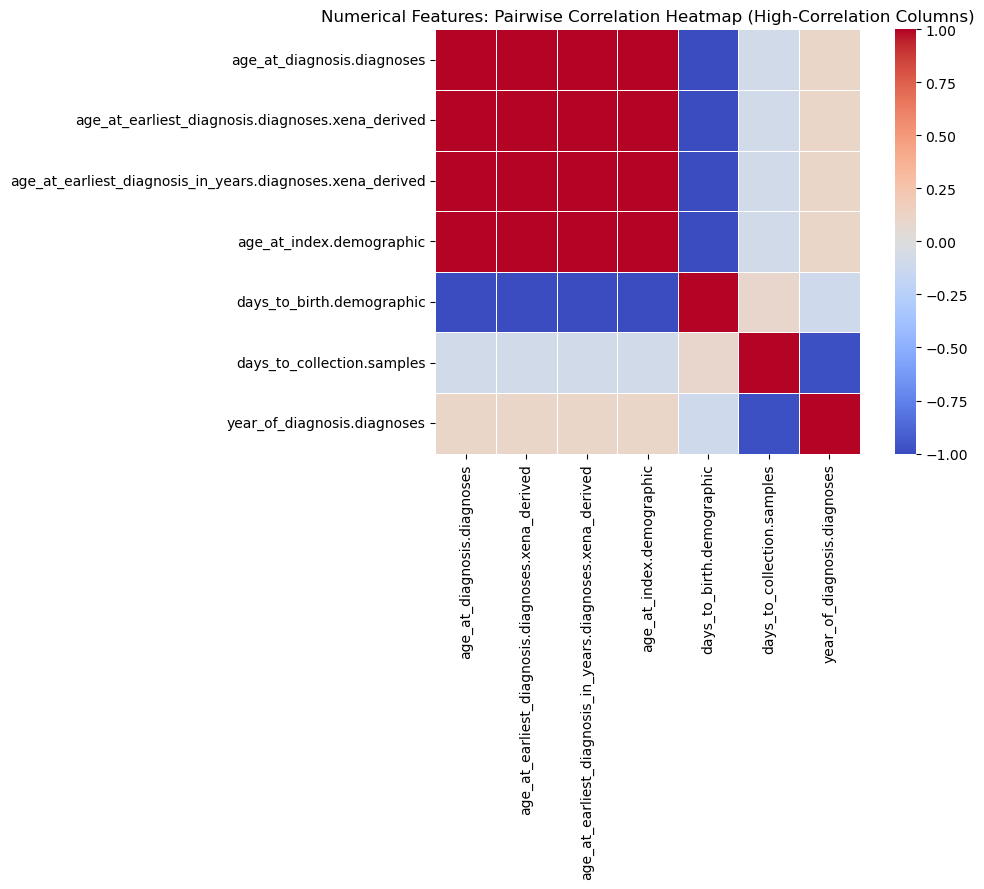

In [8]:
# Numeric redundancy

num_cols = clin_df.select_dtypes(include='number').columns
corr = clin_df[num_cols].corr().abs()

# Find highly correlated pairs (upper triangle only).
high_corr = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
high_corr.columns = ['feature_1', 'feature_2', 'corr']
high_corr = high_corr[high_corr['corr'] > 0.95].sort_values('corr', ascending=False)

print(f'High-correlation pairs (>0.95): {len(high_corr)}')
display(high_corr)

# Pairwise heatmap for columns involved in high-correlation pairs.

high_corr_cols = sorted(set(high_corr['feature_1']).union(high_corr['feature_2']))
corr_sub = clin_df[high_corr_cols].corr()

plt.figure(figsize=(1.2 * len(high_corr_cols) + 3, 1.0 * len(high_corr_cols) + 2))
sns.heatmap(
    corr_sub,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
)
plt.title('Numerical Features: Pairwise Correlation Heatmap (High-Correlation Columns)')
plt.tight_layout()
plt.show()


In [9]:
# days_to_collection.samples and year_of_diagnosis.diagnoses show moderate correlation because calendar time moves together, but they measure different things.
clin_df[["days_to_collection.samples","year_of_diagnosis.diagnoses"]].describe()

,days_to_collection.samples,year_of_diagnosis.diagnoses
count,290.000000,290.000000
mean,2182.434483,2004.606897
std,1601.990411,4.575089
min,30.000000,1988.000000
25%,1164.000000,2003.000000
50%,1782.500000,2006.000000
75%,2733.500000,2007.000000
max,7820.000000,2013.000000


In [10]:
# Check pairwise deterministic relationships between categorical variables, which can indicate redundant encodings or hierarchical relationships.

# Select categorical columns only
cat_cols = clin_df.select_dtypes("object").columns

pairs = []

# Loop over each unique pair of categorical columns
for i, c1 in enumerate(cat_cols):
    for c2 in cat_cols[i+1:]:

        # Keep only rows where both columns are present
        # This avoids treating missing values as categories
        s = clin_df[[c1, c2]].dropna()

        # Skip pairs with no overlapping non-missing data
        if s.empty:
            continue

        # Count how many unique values each column has
        n1, n2 = s[c1].nunique(), s[c2].nunique()

        # Skip pairs where either column is constant
        # Constant columns create trivial "deterministic" mappings
        # that are not useful for redundancy detection
        if n1 <= 1 or n2 <= 1:
            continue

        # Check whether c1 determines c2:
        # for each value of c1, is there only one observed value of c2?
        c1_to_c2 = s.groupby(c1)[c2].nunique().max() == 1

        # Check whether c2 determines c1:
        # for each value of c2, is there only one observed value of c1?
        c2_to_c1 = s.groupby(c2)[c1].nunique().max() == 1

        # Classify the relationship
        if c1_to_c2 and c2_to_c1:
            # Perfect one-to-one mapping: likely duplicate encodings
            pairs.append((c1, c2, "one-to-one"))
        elif c1_to_c2:
            # c1 fully determines c2
            pairs.append((c1, c2, "c1->c2"))
        elif c2_to_c1:
            # c2 fully determines c1
            pairs.append((c1, c2, "c2->c1"))

# Display all categorical pairs with deterministic relationships
pd.DataFrame(pairs, columns=["col1", "col2", "relation"])

,col1,col2,relation
0,disease_type,primary_diagnosis.diagnoses,c2->c1
1,disease_type,morphology.diagnoses,c2->c1
2,tissue_source_site_id.tissue_source_site,code.tissue_source_site,one-to-one
3,tissue_source_site_id.tissue_source_site,name.tissue_source_site,one-to-one
4,code.tissue_source_site,name.tissue_source_site,one-to-one
5,synchronous_malignancy.diagnoses,prior_malignancy.diagnoses,one-to-one
6,tissue_or_organ_of_origin.diagnoses,icd_10_code.diagnoses,one-to-one
7,tissue_or_organ_of_origin.diagnoses,site_of_resection_or_biopsy.diagnoses,one-to-one
8,primary_diagnosis.diagnoses,morphology.diagnoses,one-to-one
9,icd_10_code.diagnoses,site_of_resection_or_biopsy.diagnoses,one-to-one


In [11]:
# Manual check, if each row maps to exactly one volumn value, then there is a deterministic mapping.


pd.crosstab(clin_df['primary_diagnosis.diagnoses'], clin_df['disease_type'])

disease_type,Adnexal and Skin Appendage Neoplasms,Complex Epithelial Neoplasms,"Cystic, Mucinous and Serous Neoplasms",Ductal and Lobular Neoplasms,"Epithelial Neoplasms, NOS",Squamous Cell Neoplasms
primary_diagnosis.diagnoses,,,,,,
Apocrine adenocarcinoma,1,0,0,0,0,0
Infiltrating duct and lobular carcinoma,0,0,0,8,0,0
"Infiltrating duct carcinoma, NOS",0,0,0,207,0,0
Infiltrating duct mixed with other types of carcinoma,0,0,0,5,0,0
Large cell neuroendocrine carcinoma,0,0,0,0,1,0
"Lobular carcinoma, NOS",0,0,0,56,0,0
"Medullary carcinoma, NOS",0,0,0,1,0,0
"Metaplastic carcinoma, NOS",0,3,0,0,0,0
Mucinous adenocarcinoma,0,0,2,0,0,0


Categorical columns (total): 24
Variables with >=1 Cramer's V > 0.7: 12


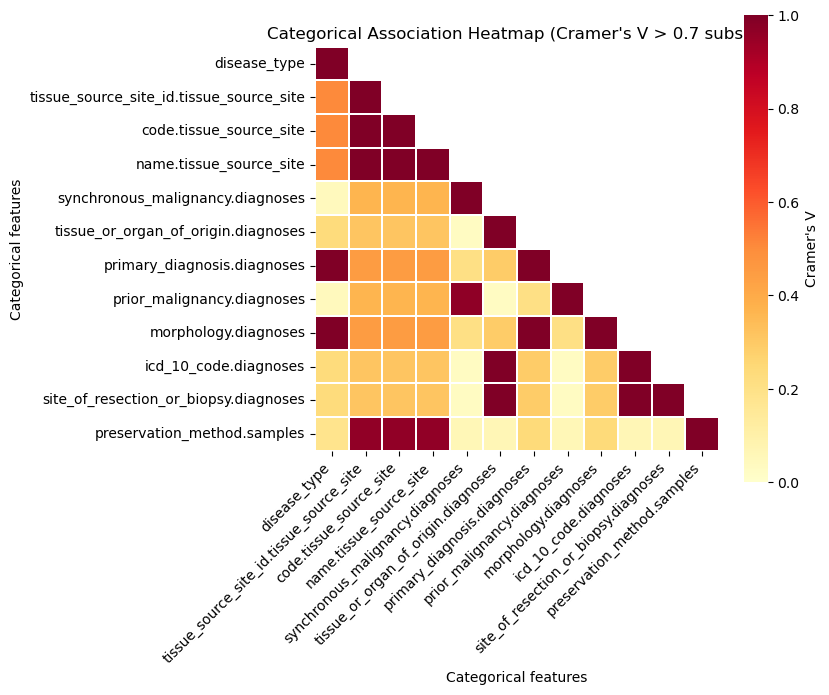

In [12]:
# Cramér’s V measures association strength between categorical variables.
# 0.0-0.3  weak
# 0.3-0.7  moderate
# 0.7-1.0  very strong


def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    if confusion.empty:
        return np.nan

    # Need at least a 2x2 contingency table for a meaningful association.
    if confusion.shape[0] < 2 or confusion.shape[1] < 2:
        return np.nan

    chi2 = ss.chi2_contingency(confusion)[0]
    n = confusion.to_numpy().sum()
    if n == 0:
        return np.nan

    phi2 = chi2 / n
    r, k = confusion.shape
    denom = min(k - 1, r - 1)
    if denom <= 0:
        return np.nan

    return np.sqrt(phi2 / denom)

# Build pairwise Cramer's V matrix for categorical columns.
cat_cols = clin_df.select_dtypes(include=['object', 'category']).columns.tolist()
if len(cat_cols) < 2:
    raise ValueError('Need at least 2 categorical columns for Cramer\'s V heatmap')

cramers_matrix = pd.DataFrame(np.nan, index=cat_cols, columns=cat_cols)

for c1 in cat_cols:
    for c2 in cat_cols:
        if c1 == c2:
            cramers_matrix.loc[c1, c2] = 1.0
            continue

        pair_df = clin_df[[c1, c2]].dropna()
        if pair_df.empty:
            continue

        cramers_matrix.loc[c1, c2] = cramers_v(pair_df[c1], pair_df[c2])

# Keep only variables that have at least one off-diagonal score > 0.7.
threshold = 0.7
off_diag = cramers_matrix.where(~np.eye(len(cramers_matrix), dtype=bool))
keep_vars = off_diag.gt(threshold).any(axis=1)
selected_cols = keep_vars[keep_vars].index.tolist()

print(f'Categorical columns (total): {len(cat_cols)}')
print(f'Variables with >=1 Cramer\'s V > {threshold}: {len(selected_cols)}')

if len(selected_cols) < 2:
    print('Fewer than 2 variables meet the threshold; heatmap not generated.')
else:
    cramers_matrix_plot = cramers_matrix.loc[selected_cols, selected_cols].astype(float)

    plt.figure(figsize=(max(8, 0.7 * len(selected_cols)), max(6, 0.6 * len(selected_cols))))
    mask = np.triu(np.ones_like(cramers_matrix_plot, dtype=bool), k=1)
    ax = sns.heatmap(
        cramers_matrix_plot,
        mask=mask,
        cmap='YlOrRd',
        vmin=0,
        vmax=1,
        square=True,
        linewidths=0.3,
        cbar_kws={'label': "Cramer's V"},
    )
    ax.set_title("Categorical Association Heatmap (Cramer's V > 0.7 subset)")
    ax.set_xlabel('Categorical features')
    ax.set_ylabel('Categorical features')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


### Redundancy decisions

These are essentially the same age variable
- Columns: 
    - age_at_diagnosis.diagnoses
    - age_at_earliest_diagnosis.diagnoses.xena_derived
    - age_at_earliest_diagnosis_in_years.diagnoses.xena_derived
    - age_at_index.demographic
    - days_to_birth.demographic
- Decision:
    - KEEP
        - age_at_earliest_diagnosis_in_years.diagnoses.xena_derived
    - DROP
        - age_at_diagnosis.diagnoses
        - age_at_earliest_diagnosis.diagnoses.xena_derived
        - age_at_index.demographic
        - days_to_birth.demographic
- Reason:
    - They encode the same age signal
    - Keep a direct years-based variable

These are different encodings of tissue source site
- Columns: 
    - tissue_source_site_id.tissue_source_site
    - code.tissue_source_site
    - name.tissue_source_site
- Decision:
    - KEEP
        - name.tissue_source_site
    - DROP
        - tissue_source_site_id.tissue_source_site
        - code.tissue_source_site
- Reason:
    - Name is the most interpretable representation

These encode overlapping diagnosis information
- Columns: 
    - disease_type
    - primary_diagnosis.diagnoses
    - morphology.diagnoses
- Decision:
    - KEEP
        - primary_diagnosis.diagnoses
    - DROP
        - disease_type
        - morphology.diagnoses
- Reason:
    - primary_diagnosis.diagnoses is the most granular standard clinical field

These have a one-to-one mapping
- Columns: 
    - synchronous_malignancy.diagnoses
    - prior_malignancy.diagnoses
- Decision:
    - KEEP
        - prior_malignancy.diagnoses
    - DROP
        - synchronous_malignancy.diagnoses
- Reason:
    - prior_malignancy.diagnoses is more clinically interpretable

These all represent the same anatomical site
- Columns: 
    - tissue_or_organ_of_origin.diagnoses
    - icd_10_code.diagnoses
    - site_of_resection_or_biopsy.diagnoses
- Decision:
    - KEEP
        - tissue_or_organ_of_origin.diagnoses
    - DROP
        - icd_10_code.diagnoses
        - site_of_resection_or_biopsy.diagnoses
- Reason:
    - ICD codes are less interpretable
    - tissue_or_organ_of_origin is clearer


## 5. Encode preprocessing rules  

In [13]:
# Imputation rules derived from missingness analysis

NUMERIC_MEDIAN_IMPUTE = [
    "age_at_earliest_diagnosis_in_years.diagnoses.xena_derived",
    "initial_weight.samples",
]

CATEGORICAL_FILL_UNKNOWN = [
    "ajcc_staging_system_edition.diagnoses"
]

In [14]:
# Manual semantic drops (redundant encodings, interpretation decisions)
MANUAL_DROP_COLS = [
    'age_at_diagnosis.diagnoses',
    'age_at_earliest_diagnosis.diagnoses.xena_derived',
    'age_at_index.demographic',
    'days_to_birth.demographic',
    'tissue_source_site_id.tissue_source_site',
    'code.tissue_source_site',
    'disease_type',
    'morphology.diagnoses',
    'synchronous_malignancy.diagnoses',
    'icd_10_code.diagnoses',
    'site_of_resection_or_biopsy.diagnoses',
]

# Sanity checks
if len(MANUAL_DROP_COLS) != len(set(MANUAL_DROP_COLS)):
    raise ValueError('MANUAL_DROP_COLS contains duplicate entries')

missing_manual_cols = [c for c in MANUAL_DROP_COLS if c not in clin_df.columns]
if missing_manual_cols:
    raise KeyError(f'MANUAL_DROP_COLS missing from clin_df: {missing_manual_cols}')

constant_cols = list(constant_cols)
DROP_COLS = list(dict.fromkeys(MANUAL_DROP_COLS + constant_cols))

# Every final drop column must come from manual list or detected constant columns.
allowed_drop_cols = set(MANUAL_DROP_COLS).union(constant_cols)
unexpected_drop_cols = [c for c in DROP_COLS if c not in allowed_drop_cols]
if unexpected_drop_cols:
    raise ValueError(f'Unexpected columns in DROP_COLS: {unexpected_drop_cols}')

print(f'MANUAL_DROP_COLS: {len(MANUAL_DROP_COLS)}')
print(f'constant_cols: {len(constant_cols)}')
print(f'DROP_COLS (combined, deduplicated): {len(DROP_COLS)}')
display(DROP_COLS)


MANUAL_DROP_COLS: 11
constant_cols: 20
DROP_COLS (combined, deduplicated): 31


['age_at_diagnosis.diagnoses',
 'age_at_earliest_diagnosis.diagnoses.xena_derived',
 'age_at_index.demographic',
 'days_to_birth.demographic',
 'tissue_source_site_id.tissue_source_site',
 'code.tissue_source_site',
 'disease_type',
 'morphology.diagnoses',
 'synchronous_malignancy.diagnoses',
 'icd_10_code.diagnoses',
 'site_of_resection_or_biopsy.diagnoses',
 'primary_site',
 'alcohol_history.exposures',
 'primary_site.project',
 'project_id.project',
 'disease_type.project',
 'name.project',
 'name.program.project',
 'project.tissue_source_site',
 'bcr_id.tissue_source_site',
 'last_known_disease_status.diagnoses',
 'classification_of_tumor.diagnoses',
 'tumor_grade.diagnoses',
 'progression_or_recurrence.diagnoses',
 'state.treatments.diagnoses',
 'tumor_descriptor.samples',
 'sample_type.samples',
 'composition.samples',
 'specimen_type.samples',
 'is_ffpe.samples',
 'tissue_type.samples']